In [1]:
import spacy, matplotlib.pyplot as plt, pandas as pd, numpy as np
from spacy import displacy
from spacy.training import Example
from spacy.matcher import Matcher, PhraseMatcher

from sklearn.decomposition import PCA
#!python -m spacy download en_core_web_md
!python -m spacy download en_core_web_lg
# nlp = spacy.load("en_core_web_sm")
nlp = spacy.load("en_core_web_lg")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# New Section

# **Natural Language Processing (NLP) basics**

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("A spaCy pipeline object is created.")
[i for i in doc]

[A, spaCy, pipeline, object, is, created, .]

## **Tokenization**

In [ ]:
[token.text for token in doc]

['A', 'spaCy', 'pipeline', 'object', 'is', 'created', '.']

#### ***Exercise: Doc container in spaCy***
The first step of a spaCy text processing pipeline is to convert a given text string into a `Doc` container, which stores the processed text. In this exercise, you'll practice loading a `spaCy` model, creating an `nlp()`object, creating a `Doc` container and processing a `text` string that is available for you.

#### ***Instructions***

* Load `en_core_web_sm` and create an `nlp` object.
* Create a `doc` container of the `text` string.
* Create a list containing the text of each tokens in the `doc` container.



In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
text = 'NLP is becoming increasingly popular for providing business solutions.'


doc = nlp(text)
print([i.text for i in doc])

['NLP', 'is', 'becoming', 'increasingly', 'popular', 'for', 'providing', 'business', 'solutions', '.']


#### ***Exercise: Tokenization with spaCy***

Use the first review from the Amazon Fine Food Reviews dataset for this exercise. You can access this review by using the `text` object provided.

#### ***Instructions***

* Store `Doc` container for the pre-loaded review in a `document` object.
- Store and review texts of all the tokens of the `document` in the variable `first_text_tokens`

In [ ]:
text = 'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

document = nlp(text)
first_text_tokens = [i.text for i in document]
print("First text tokens:\n", first_text_tokens, "\n")

First text tokens:
 ['I', 'have', 'bought', 'several', 'of', 'the', 'Vitality', 'canned', 'dog', 'food', 'products', 'and', 'have', 'found', 'them', 'all', 'to', 'be', 'of', 'good', 'quality', '.', 'The', 'product', 'looks', 'more', 'like', 'a', 'stew', 'than', 'a', 'processed', 'meat', 'and', 'it', 'smells', 'better', '.', 'My', 'Labrador', 'is', 'finicky', 'and', 'she', 'appreciates', 'this', 'product', 'better', 'than', ' ', 'most', '.'] 



## **Sentence segmentation**

In [ ]:
doc = nlp("We are learning NLP. This course introduces spaCy.")
[i.text for i in doc.sents]

['We are learning NLP.', 'This course introduces spaCy.']

## **Lemmatization**


In [ ]:
doc = nlp("We are seeing her after one year.")
[(token.text, token.lemma_ )for token in doc]

[('We', 'we'),
 ('are', 'be'),
 ('seeing', 'see'),
 ('her', 'she'),
 ('after', 'after'),
 ('one', 'one'),
 ('year', 'year'),
 ('.', '.')]

#### ***Exercise: Running a spaCy pipeline***

#### ***Instructions***

* Run an `nlp()` model on each item of `texts`, and append each corresponding `Doc` container to a `documents` list.

* Print the token texts for each `Doc` container of the `documents` list.

In [ ]:
texts = ['A loaded spaCy model can be used to compile documents list!', 'Tokenization is the first step in any spacy pipeline.']

documents = [nlp(i) for i in texts]
for doc in documents:
    print([i.text for i in doc])

['A', 'loaded', 'spaCy', 'model', 'can', 'be', 'used', 'to', 'compile', 'documents', 'list', '!']
['Tokenization', 'is', 'the', 'first', 'step', 'in', 'any', 'spacy', 'pipeline', '.']


#### ***Exercise: Lemmatization with spaCy***

#### ***Instructions***

* Append the lemma for all tokens in the `document`, then print the list of `lemmas`.
- Print `tokens` list and observe the differences between `tokens` and `lemmas`.

In [ ]:
text = 'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

document = nlp(text)
tokens = [token.text for token in document]
lemmas = [token.lemma_ for token in document]

print("Lemmas:\n", lemmas, "\n")
print("Tokens:\n", tokens)

Lemmas:
 ['I', 'have', 'buy', 'several', 'of', 'the', 'Vitality', 'can', 'dog', 'food', 'product', 'and', 'have', 'find', 'they', 'all', 'to', 'be', 'of', 'good', 'quality', '.', 'the', 'product', 'look', 'more', 'like', 'a', 'stew', 'than', 'a', 'process', 'meat', 'and', 'it', 'smell', 'well', '.', 'my', 'Labrador', 'be', 'finicky', 'and', 'she', 'appreciate', 'this', 'product', 'well', 'than', ' ', 'most', '.'] 

Tokens:
 ['I', 'have', 'bought', 'several', 'of', 'the', 'Vitality', 'canned', 'dog', 'food', 'products', 'and', 'have', 'found', 'them', 'all', 'to', 'be', 'of', 'good', 'quality', '.', 'The', 'product', 'looks', 'more', 'like', 'a', 'stew', 'than', 'a', 'processed', 'meat', 'and', 'it', 'smells', 'better', '.', 'My', 'Labrador', 'is', 'finicky', 'and', 'she', 'appreciates', 'this', 'product', 'better', 'than', ' ', 'most', '.']


#### ***Exercise: Sentence segmentation with spaCy***



In [ ]:
texts = ['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.',
 'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".',
 'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.',
 'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.',
 'Great taffy at a great price.  There was a wide assortment of yummy taffy.  Delivery was very quick.  If your a taffy lover, this is a deal.',
 'I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable with many flavors: watermelon, root beer, melon, peppermint, grape, etc. My only complaint is there was a bit too much red/black licorice-flavored pieces (just not my particular favorites). Between me, my kids, and my husband, this lasted only two weeks! I would recommend this brand of taffy -- it was a delightful treat.',
 "This saltwater taffy had great flavors and was very soft and chewy.  Each candy was individually wrapped well.  None of the candies were stuck together, which did happen in the expensive version, Fralinger's.  Would highly recommend this candy!  I served it at a beach-themed party and everyone loved it!",
 'This taffy is so good.  It is very soft and chewy.  The flavors are amazing.  I would definitely recommend you buying it.  Very satisfying!!',
 "Right now I'm mostly just sprouting this so my cats can eat the grass. They love it. I rotate it around with Wheatgrass and Rye too",
 'This is a very healthy dog food. Good for their digestion. Also good for small puppies. My dog eats her required amount at every feeding.']

# Generating a documents list of all Doc containers
documents = [nlp(text) for text in texts]

# Iterate through documents and append sentences in each doc to the sentences list
sentences = []
for doc in documents:
    sentences.append([s for s in doc.sents])

# Find number of sentences per each doc container
print([len(s) for s in sentences])

[3, 2, 7, 3, 4, 5, 5, 5, 3, 4]


# **Linguistic features in spaCy**

In [ ]:
sent = "I left without my watch."

print([(token.text, token.pos_, spacy.explain(token.pos_)) for token in nlp(sent)])

[('I', 'PRON', 'pronoun'), ('left', 'VERB', 'verb'), ('without', 'ADP', 'adposition'), ('my', 'PRON', 'pronoun'), ('watch', 'NOUN', 'noun'), ('.', 'PUNCT', 'punctuation')]


## **Named entity recognition**

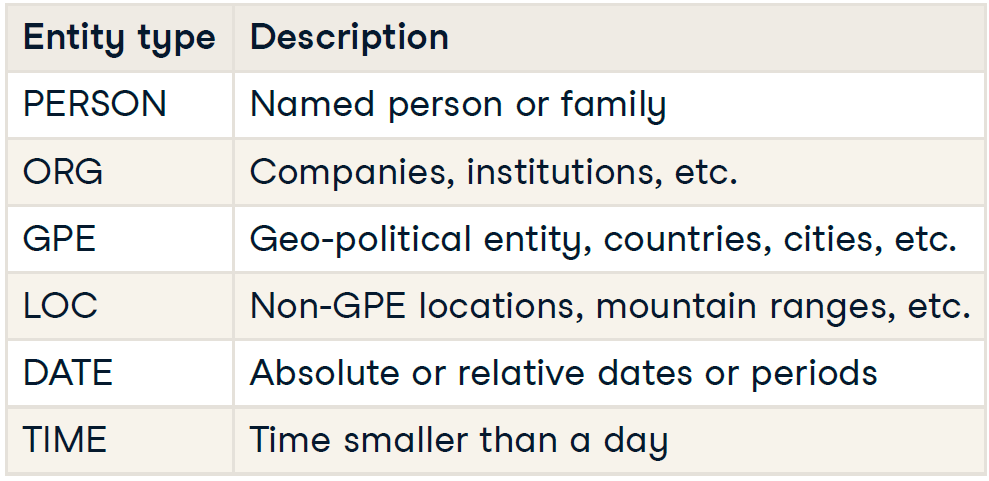

## **NER and spaCY**

In [ ]:
doc = nlp("Albert Einstein was genius.")

print([(ent.text, ent.start_char, ent.end_char, ent.label_) for ent in doc.ents])

[('Albert Einstein', 0, 15, 'PERSON')]


In [ ]:
print([(token.text, token.ent_type_) for token in doc])

[('Albert', 'PERSON'), ('Einstein', 'PERSON'), ('was', ''), ('genius', ''), ('.', '')]


In [ ]:
displacy.render(doc, style="ent")

#### ***Exercise: POS tagging with spaCy***

POS tagging is a useful tool in NLP as it allows algorithms to understand the grammatical structure of a sentence and to confirm words that have multiple meanings such as `watch` and `play`.


#### ***Instructions***

- Compile `documents`, a list of all `doc` containers for each text in `texts` list using list comprehension.

- For each `doc` container, print each token's text and its corresponding POS tag by iterating through `documents` and tokens of each `doc` container using a nested for loop.

In [ ]:
texts = ['What is the arrival time in San francisco for the 7:55 AM flight leaving Washington?',
 'Cheapest airfare from Tacoma to Orlando is 650 dollars.',
 'Round trip fares from Pittsburgh to Philadelphia are under 1000 dollars!']


# Compile a list of all Doc containers of texts
documents = [nlp(text) for text in texts]

# Print token texts and POS tags for each Doc container
for doc in documents:
    for token in doc:
        print("Text: ", token.text, "| POS tag: ", token.pos_)
    print("\n")

Text:  What | POS tag:  PRON
Text:  is | POS tag:  AUX
Text:  the | POS tag:  DET
Text:  arrival | POS tag:  NOUN
Text:  time | POS tag:  NOUN
Text:  in | POS tag:  ADP
Text:  San | POS tag:  PROPN
Text:  francisco | POS tag:  PROPN
Text:  for | POS tag:  ADP
Text:  the | POS tag:  DET
Text:  7:55 | POS tag:  NUM
Text:  AM | POS tag:  PROPN
Text:  flight | POS tag:  NOUN
Text:  leaving | POS tag:  VERB
Text:  Washington | POS tag:  PROPN
Text:  ? | POS tag:  PUNCT


Text:  Cheapest | POS tag:  PROPN
Text:  airfare | POS tag:  NOUN
Text:  from | POS tag:  ADP
Text:  Tacoma | POS tag:  PROPN
Text:  to | POS tag:  ADP
Text:  Orlando | POS tag:  PROPN
Text:  is | POS tag:  AUX
Text:  650 | POS tag:  NUM
Text:  dollars | POS tag:  NOUN
Text:  . | POS tag:  PUNCT


Text:  Round | POS tag:  ADJ
Text:  trip | POS tag:  NOUN
Text:  fares | POS tag:  NOUN
Text:  from | POS tag:  ADP
Text:  Pittsburgh | POS tag:  PROPN
Text:  to | POS tag:  ADP
Text:  Philadelphia | POS tag:  PROPN
Text:  are | P

#### ***Exercise: NER with spaCy***

#### ***Instructions***

- Compile `documents`, a list of all `Doc` containers for each text in the `texts `using list comprehension.

- For each `doc` container, print each entity's text and corresponding label by iterating through `doc.ents`.

- Print the sixth token's text, and the entity type of the second `Doc` container.

In [ ]:
texts = ['I want to fly from Boston at 8:38 am and arrive in Denver at 11:10 in the morning',
 'What flights are available from Pittsburgh to Baltimore on Thursday morning?',
 'What is the arrival time in San francisco for the 7:55 AM flight leaving Washington?']


documents = [nlp(text) for text in texts]
for doc in documents:
    print([(ent.text, ent.label_) for ent in doc.ents])

# Print the 6th token's text and entity type of the second document
print("\nText:", documents[1][5].text, "| Entity type: ", documents[1][5].ent_type_)

[('Boston', 'GPE'), ('8:38 am', 'TIME'), ('Denver', 'GPE'), ('11:10 in the morning', 'TIME')]
[('Pittsburgh', 'GPE'), ('Baltimore', 'GPE'), ('Thursday', 'DATE'), ('morning', 'TIME')]
[('San francisco', 'GPE'), ('7:55 AM', 'TIME'), ('Washington', 'GPE')]

Text: Pittsburgh | Entity type:  GPE


#### ***Exercise: Text processing with spaCy***

Every NLP application consists of several text processing steps. You have already learned some of these steps, including tokenization, lemmatization, sentence segmentation and named entity recognition.

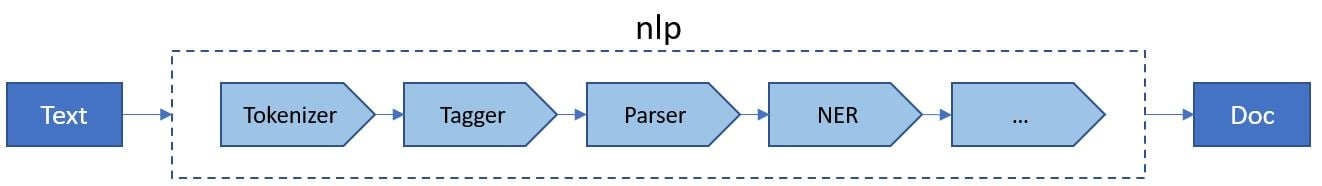

In this exercise, you'll continue to practice with text processing steps in spaCy, such as breaking the text into sentences and extracting named entities.

#### ***Instructions***

- Create `sentences`, a list of list of all sentences in each `doc` container in `documents` using list comprehension.
- Print `num_sentences`, a list containing the number of sentences for each `doc` container by using the `len()` method.

- Create a list of tuples of format (entity text, entity label) for the third `doc` container in `third_text_entities`.

- Create a list of tuples of format (token text, POS tag) of first ten tokens of third `doc` container at `third_text_10_pos`.

In [ ]:
texts = ['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.',
 'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".',
 'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.',
 'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.',
 'Great taffy at a great price.  There was a wide assortment of yummy taffy.  Delivery was very quick.  If your a taffy lover, this is a deal.',
 'I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable with many flavors: watermelon, root beer, melon, peppermint, grape, etc. My only complaint is there was a bit too much red/black licorice-flavored pieces (just not my particular favorites). Between me, my kids, and my husband, this lasted only two weeks! I would recommend this brand of taffy -- it was a delightful treat.',
 "This saltwater taffy had great flavors and was very soft and chewy.  Each candy was individually wrapped well.  None of the candies were stuck together, which did happen in the expensive version, Fralinger's.  Would highly recommend this candy!  I served it at a beach-themed party and everyone loved it!",
 'This taffy is so good.  It is very soft and chewy.  The flavors are amazing.  I would definitely recommend you buying it.  Very satisfying!!',
 "Right now I'm mostly just sprouting this so my cats can eat the grass. They love it. I rotate it around with Wheatgrass and Rye too",
 'This is a very healthy dog food. Good for their digestion. Also good for small puppies. My dog eats her required amount at every feeding.']

# Generating a documents list of all Doc containers
documents = [nlp(text) for text in texts]

In [ ]:
# Create a list to store sentences of each Doc container in documents
sentences = [[sent for sent in doc.sents] for doc in documents]

# Create a list to track number of sentences per Doc container in documents
num_sentences = [len([sent for sent in doc.sents]) for doc in documents]
print("Number of sentences in documents:\n", num_sentences, "\n")

# Record entities text and corresponding label of the third Doc container
third_text_entities = [(ent.text, ent.label_) for ent in documents[2].ents]
print("Third text entities:\n", third_text_entities, "\n")

# Record first ten tokens and corresponding POS tag for the third Doc container
third_text_10_pos = [(token.text, token.pos_) for token in documents[2]][:10]
print("First ten tokens of third text:\n", third_text_10_pos)

Number of sentences in documents:
 [3, 2, 7, 3, 4, 5, 5, 5, 3, 4] 

Third text entities:
 [('around a few centuries', 'DATE'), ('pillowy citrus gelatin', 'ORG'), ('Filberts', 'GPE'), ("C.S. Lewis'", 'ORG'), ('The Lion, The Witch', 'WORK_OF_ART'), ('Edmund', 'PRODUCT'), ('Sisters', 'PERSON'), ('Witch', 'ORG')] 

First ten tokens of third text:
 [('This', 'PRON'), ('is', 'AUX'), ('a', 'DET'), ('confection', 'NOUN'), ('that', 'PRON'), ('has', 'AUX'), ('been', 'AUX'), ('around', 'ADP'), ('a', 'DET'), ('few', 'ADJ')]


# **POS tagging**



In [ ]:
text = "My cat will fish for a fish tomorrrow in a fishy way."

for token in nlp(text):
    print(token.text, spacy.explain(token.pos_))

My pronoun
cat noun
will auxiliary
fish verb
for adposition
a determiner
fish noun
tomorrrow noun
in adposition
a determiner
fishy adjective
way noun
. punctuation


## **Word-sense disambiguation**



In [ ]:
verb_text = "I will fish tomorrow."
noun_text = "I ate fish."

print([(token.text, token.pos_) for token in nlp(verb_text) if "fish" in token.text], "\n")
print([(token.text, token.pos_) for token in nlp(noun_text) if "fish" in token.text])

[('fish', 'VERB')] 

[('fish', 'NOUN')]


In [ ]:
doc = nlp("We understand the differences.")

spacy.displacy.render(doc, style="dep")

In [ ]:
for token in doc:
    print(token.text, ': ', spacy.explain(token.dep_))

We :  nominal subject
understand :  root
the :  determiner
differences :  direct object
. :  punctuation


#### ***Exercise: Word-sense disambiguation with spaCy***

In [ ]:
texts = ["This device is used to jam the signal.",
         "I am stuck in a traffic jam"]

# Create a list of Doc containers in the texts list
documents = [nlp(t) for t in texts]

# Print a token's text and POS tag if the word jam is in the token's text
for i, doc in enumerate(documents):
    print(f"Sentence {i+1}: ", [(token.text, token.pos_) for token in doc if "jam" in token.text], "\n")

Sentence 1:  [('jam', 'VERB')] 

Sentence 2:  [('jam', 'NOUN')] 



#### ***Exercise: Dependency parsing with spaCy***

In [ ]:
texts = ['I want to fly from Boston at 8:38 am and arrive in Denver at 11:10 in the morning',
 'What flights are available from Pittsburgh to Baltimore on Thursday morning?',
 'What is the arrival time in San francisco for the 7:55 AM flight leaving Washington?']

 # Create a list of Doc containts of texts list
documents = [nlp(t) for t in texts]

# Print each token's text, dependency label and its explanation
for doc in documents:
    print([(token.text, token.dep_, spacy.explain(token.dep_)) for token in doc], "\n")

[('I', 'nsubj', 'nominal subject'), ('want', 'ROOT', 'root'), ('to', 'aux', 'auxiliary'), ('fly', 'xcomp', 'open clausal complement'), ('from', 'prep', 'prepositional modifier'), ('Boston', 'pobj', 'object of preposition'), ('at', 'prep', 'prepositional modifier'), ('8:38', 'nummod', 'numeric modifier'), ('am', 'pobj', 'object of preposition'), ('and', 'cc', 'coordinating conjunction'), ('arrive', 'conj', 'conjunct'), ('in', 'prep', 'prepositional modifier'), ('Denver', 'pobj', 'object of preposition'), ('at', 'prep', 'prepositional modifier'), ('11:10', 'pobj', 'object of preposition'), ('in', 'prep', 'prepositional modifier'), ('the', 'det', 'determiner'), ('morning', 'pobj', 'object of preposition')] 

[('What', 'det', 'determiner'), ('flights', 'nsubj', 'nominal subject'), ('are', 'ROOT', 'root'), ('available', 'acomp', 'adjectival complement'), ('from', 'prep', 'prepositional modifier'), ('Pittsburgh', 'pobj', 'object of preposition'), ('to', 'prep', 'prepositional modifier'), ('B

# **Word vectors**

- A pre-defined number of dimensions
- Considers word frequencies and the presence of other words in similar contexts

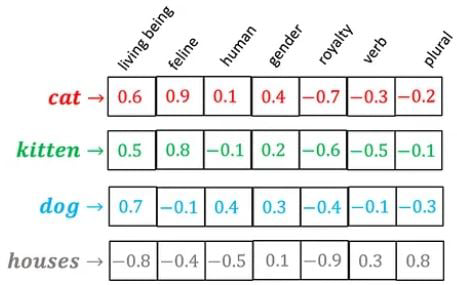

In [ ]:
nlp = spacy.load("en_core_web_md")
print(nlp.meta["vectors"])

{'width': 300, 'vectors': 20000, 'keys': 684830, 'name': 'en_vectors', 'mode': 'default'}


In [ ]:
nlp.vocab.strings['like']

18194338103975822726

In [ ]:
id = nlp.vocab.strings['like']
nlp.vocab.vectors[id]

array([-6.1052e-01,  1.1656e-01, -5.0648e-01, -3.2216e-01, -9.9742e-02,
        1.0182e-01,  3.1042e-01, -1.8155e-01,  3.1774e-01,  2.1537e+00,
       -8.1129e-02, -3.8734e-01,  6.8008e-02, -5.8029e-03, -5.3814e-01,
       -9.8787e-02, -8.4160e-02,  3.1755e-02, -2.9811e-01,  5.0496e-01,
        4.1719e-01,  1.1462e-01,  2.5330e-01, -1.6668e-01,  2.6645e-02,
        4.5709e-02, -5.9685e-01, -3.9645e-01,  4.3089e-01,  1.3014e-01,
       -4.0591e-02,  6.6024e-01, -5.3007e-01, -8.1629e-02,  3.3484e-01,
        1.6258e-01,  3.9029e-02,  7.2786e-02, -1.8635e-01,  3.8104e-01,
       -5.0557e-01, -3.0910e-02, -3.2578e-01,  3.8818e-01,  1.4605e-01,
        3.8982e-02, -1.4992e-01,  6.0316e-01, -3.0801e-02,  1.3456e-01,
       -6.2982e-01,  5.8746e-02,  1.5878e-02, -7.8831e-02,  1.4754e-01,
        5.2191e-02, -4.3654e-01, -1.6707e-01, -1.5184e-02, -1.6073e-01,
       -2.1243e-02,  8.3719e-02, -6.5062e-01, -7.9566e-02, -4.5479e-02,
       -1.0070e-01, -1.4044e-01, -4.1403e-02,  1.2033e-01,  2.60

#### ***Exercise: spaCy vocabulary***

Word vectors, or word embeddings, are numerical representations of words that allow computers to perform complex tasks using text data. Word vectors are a part of many **`spaCy`** models, however, a few of the models do not have word vectors.

In this exercise, you will practice accessing **`spaCy`** vocabulary information. Some meta information about word vectors are stored in each **`spaCy`** model. You can access this information to learn more about the vocabulary size, word vectors dimensions, etc.

In a spaCy model's metadata, the number of words is stored as an element with the "**vectors**" key and the dimension of word vectors is stored as an element with the "**width**" key.

#### ***Instructions***

- Load the `en_core_web_md` model.
- Print the number of words in the `en_core_web_md` model's vocabulary.
- Print the dimensions of word vectors in the `en_core_web_md` model.


In [ ]:
# Load the en_core_web_md model
md_nlp = spacy.load('en_core_web_md')

# Print the number of words in the model's vocabulary
print("Number of words: ", md_nlp.meta["vectors"]["vectors"], "\n")

# Print the dimensions of word vectors in en_core_web_md model
print("Dimension of word vectors: ", md_nlp.meta["vectors"]["width"])

Number of words:  20000 

Dimension of word vectors:  300


#### ***Exercise: Word vectors in spaCy vocabulary***

The purpose of word vectors is to allow a computer to understand words. In this exercise, you will practice extracting word vectors for a given list of words.

A list of words is compiled as `words`. The `en_core_web_md` model is already imported and available as `nlp`.

The vocabulary of `en_core_web_md` model contains 20,000 words. If a word does not exist in the vocabulary, you will not be able to extract its corresponding word vector. In this exercise, for simplicity, it is ensured that all the given words exist in this model's vocabulary.

#### ***Instructions***

- Extract the IDs of all the given `words` and store them in an `ids` list.
For each ID from `ids`, store the first ten elements of the word vector in the `word_vectors` list.
- Print the first ten elements of the first word vector from `word_vectors`.

In [ ]:
words = ["like", "love"]

# IDs of all the given words
ids = [nlp.vocab.strings[w] for w in words]

# Store the first ten elements of the word vectors for each word
word_vectors = [nlp.vocab.vectors[i][:10] for i in ids]

# Print the first ten elements of the first word vector
print(word_vectors[0])

[-0.61052   0.11656  -0.50648  -0.32216  -0.099742  0.10182   0.31042
 -0.18155   0.31774   2.1537  ]


If a word does not exist in the vocabulary of a spaCy model, you will observe an error and will not be able to extract its corresponding word vector.

# **Word vectors and spaCy**

## **Word vectors visualization**

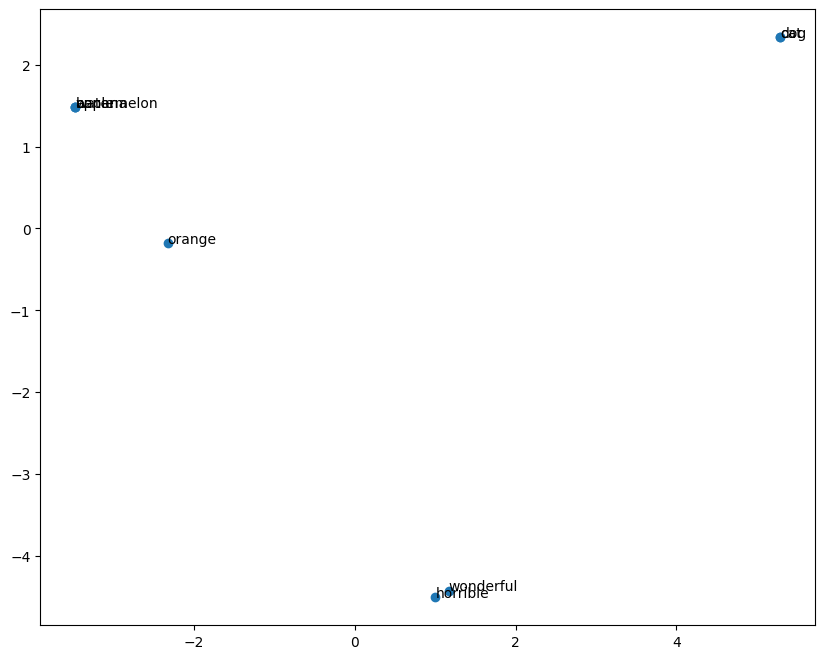

In [ ]:
words = ["wonderful", "horrible", "apple", "banana", "orange", "watermelon", "dog", "cat"]
word_vectors = np.vstack([nlp.vocab.vectors[nlp.vocab.strings[w]] for w in words])
pca = PCA(n_components=2)
word_vectors_transformed = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(word_vectors_transformed[:, 0], word_vectors_transformed[:, 1])
for word, coord in zip(words, word_vectors_transformed):
    x, y = coord
    plt.text(x, y, word, size=10)
plt.show()

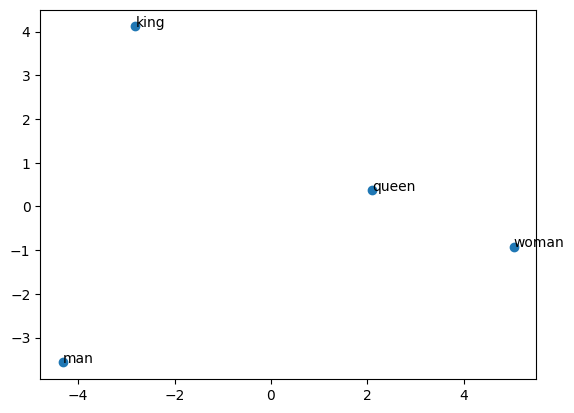

In [ ]:
def plot_word_vectors(words):
    word_vectors = np.vstack([nlp.vocab.vectors[nlp.vocab.strings[w]] for w in words])
    pca = PCA(n_components=2)
    word_vectors_transformed = pca.fit_transform(word_vectors)

    plt.figure()
    plt.scatter(word_vectors_transformed[:, 0], word_vectors_transformed[:, 1])
    for word, coord in zip(words, word_vectors_transformed):
        x, y = coord
        plt.text(x, y, word, size=10)
    plt.show()

plot_word_vectors(['man', 'king', 'woman', 'queen'])

## **Similar words in a vocabulary**

In [ ]:
nlp = spacy.load("en_core_web_lg")
word = "covid"
most_similar_words = nlp.vocab.vectors.most_similar(np.asarray([nlp.vocab.vectors[nlp.vocab.strings[word]]]), n=5)
words = [nlp.vocab.strings[w] for w in most_similar_words[0][0]]
print(words)

KeyError: '[E058] Could not retrieve vector for key 2127825066894192516.'

In [ ]:
doc = nlp("covid")
print(doc[0].has_vector)   # False for en_core_web_md
print(doc[0].vector.shape) # will still return a zero vector


False
(0,)


In [ ]:
nlp.vocab.vectors[nlp.vocab.strings['covid']]

KeyError: '[E058] Could not retrieve vector for key 2127825066894192516.'

#### ***Exercise: Word vectors projection***

You can visualize word vectors in a scatter plot to help you understand how the vocabulary words are grouped. In order to visualize word vectors, you need to project them into a two-dimensional space. You can project vectors by extracting the two principal components via Principal Component Analysis (PCA).

In this exercise, you will practice how to extract word vectors and project them into two-dimensional space using the `PCA` library from `sklearn`.

A short list of `words` that are stored in the `words` list and the `en_core_web_md` model are available for use. The model is loaded as `nlp`. All necessary libraries and packages are already imported for your use `(PCA`, `numpy` as `np`).

#### ***Instructions***

- Extract the word IDs from the given words and store them in the `word_ids` list.

- Extract the first five elements of the word vectors of the words and then stack them vertically using **`np.vstack()`** in `word_vectors`.

- Given a `pca` object, calculate the transformed word vectors using the **`.fit_transform()`** function of the `pca` class.

- Print the first component of the transformed word vectors using `[:, 0]` indexing.

In [ ]:
nlp = spacy.load('en_core_web_lg')

words = ["tiger", "bird"]

# Extract word IDs of given words
word_ids = [nlp.vocab.strings[w] for w in words]

# Extract word vectors and stack the first five elements vertically
word_vectors = np.vstack([nlp.vocab.vectors[i][:5] for i in word_ids])

# Calculate the transformed word vectors using the pca object
pca = PCA(n_components=2)
word_vectors_transformed = pca.fit_transform(word_vectors)

# Print the first component of the transformed word vectors
print(word_vectors_transformed[:, 0])

[ 0.5182773 -0.5182773]


#### ***Exercise: Similar words in a vocabulary***

Finding semantically similar terms has various applications in information retrieval. In this exercise, you will practice finding the most semantically similar term to the word ***computer*** from the `en_core_web_md` model's vocabulary.

The ***computer*** word vector is already extracted and stored as `word_vector`. The `en_core_web_md` model is already loaded as `nlp`, and NumPy package is loaded as `np`.

You can use the **`.most_similar()`** function of the **`nlp.vocab.vectors`** object to find the most semantically similar terms. Using` [0][0] `to index the output of this function will return the word IDs of the semantically similar terms. `nlp.vocab.strings[<a given word>]` can be used to find the word ID of a given word and it can similarly return the word associated with a given word ID.

#### ***Instructions***

- Find the most semantically similar term from the `en_core_web_md` vocabulary.
- Find the list of similar words given the word IDs of the similar terms.



In [ ]:
# Find the most similar word to the word computer
most_similar_words = nlp.vocab.vectors.most_similar(np.asarray([nlp.vocab.vectors[nlp.vocab.strings['computer']]]), n = 1)

# Find the list of similar words given the word IDs
words = [nlp.vocab.strings[w] for w in most_similar_words[2][0]]
print(words)

['IS_ALPHA']


## **Token similarity**

In [ ]:
nlp = spacy.load("en_core_web_md")

doc1 = nlp("We eat pizza")
doc2 = nlp("We like to eat pasta")

token1 = doc1[2]
token2 = doc2[4]

print(f"Similarity between {token1} and {token2} = ", round(token1.similarity(token2), 3))

Similarity between pizza and pasta =  1.0


## **Span similarity**



In [ ]:
doc1 = nlp("We eat pizza")
doc2 = nlp("We like to eat pasta")

span1 = doc1[1:]
span2 = doc2[1:]

print(f"Similarity between \"{span1}\" and \"{span2}\" = ", round(span1.similarity(span2), 3))
print(f"Similarity between \"{doc1[1:]}\" and \"{doc2[3:]}\" = ", round(doc1[1:].similarity(doc2[3:]), 3))

Similarity between "eat pizza" and "like to eat pasta" =  0.883
Similarity between "eat pizza" and "eat pasta" =  1.0


## **Doc similarity**

In [ ]:
nlp = spacy.load("en_core_web_md")

doc1 = nlp("I like to play basketball")
doc2 = nlp("I love to play basketball")

print("Similarity score :", round(doc1.similarity(doc2), 3))

Similarity score : 1.0


## **Sentence similarity**



In [ ]:
sentences = nlp("What is the cheapest flight from Boston to Seattle? Which airline serves Denver, Pittsburgh and Atlanta? What kinds of planes are used by American Airlines?")
keyword = nlp("price")

for i, sentence in enumerate(sentences.sents):
    print(f"Similarity score with sentence {i+1}: ", round(sentence.similarity(keyword), 5))

Similarity score with sentence 1:  0.5678
Similarity score with sentence 2:  0.34733
Similarity score with sentence 3:  0.37389


#### ***Exercise: Doc similarity with spaCy***


Semantic similarity is the process of analyzing multiple sentences to identify similarities between them. In this exercise, you will practice calculating semantic similarities of documents to a given document. The goal is to categorize a list of given reviews that are relevant to **canned dog food**.

The **canned dog food** category is stored at `category`. A sample of five food reviews has been provided for you in a list called `texts`. `en_core_web_md` is loaded as `nlp`.

#### ***Instructions***

- Create a `documents` list containing `Doc` containers of all `texts`.
- Create a `Doc` container of the `category` and store it as `category_document`.
- Iterate through `documents` and print the similarity scores of each `Doc` container and the `category_document`, rounded to three digits.

In [ ]:
texts = ['I like the Vitality canned dog food products.',
 'The peanuts were actually small sized unsalted. Not sure if this was an error.',
 'It is a light, pillowy citrus gelatin with nuts - in this case Filberts.',
 'the Root Beer Extract I ordered is very medicinal.',
 'Great taffy at a great price.']

 # Create a documents list containing Doc containers
documents = [nlp(t) for t in texts]

# Create a Doc container of the category
category = "canned dog food"
category_document = nlp(category)

# Print similarity scores of each Doc container and the category_document
for i, doc in enumerate(documents):
    print(f"Semantic similarity with document {i+1}:", round(doc.similarity(category_document), 3))

Semantic similarity with document 1: 0.762
Semantic similarity with document 2: 0.495
Semantic similarity with document 3: 0.572
Semantic similarity with document 4: 0.548
Semantic similarity with document 5: 0.36


#### ***Exercise: Span similarity with spaCy***

Determining semantic similarity can help you to categorize texts into predefined categories or detect relevant texts, or to flag duplicate content. In this exercise, you will practice calculating the semantic similarities of spans of a document to a given document. The goal is to find the most relevant `Span` of three tokens that are relevant to **canned dog food**.

In [ ]:
document = nlp("canned food products")

# Create a Doc container for the category
category = "canned dog food"
category_document = nlp(category)

# Print similarity score of a given Span and category_document
document_span = document[0:3]
print(f"Semantic similarity with", document_span.text, ":", round(document_span.similarity(category_document), 3))

Semantic similarity with canned food products : 0.8


#### ***Exercise: Semantic similarity for categorizing text***

The main objective of semantic similarity is to measure the distance between the semantic meanings of a pair of words, phrases, sentences, or documents. For example, the word “car” is more similar to “bus” than it is to “cat”. In this exercise, you will find similar sentences to the word sauce from an example text in Amazon Fine Food Reviews. You can use spacy to calculate the similarity score of the word `sauce` and any of the sentences in a given `texts` string and report the most similar sentence's score.

In [ ]:
texts = 'This hot sauce is amazing! We picked up a bottle on a trip! '

# Populate Doc containers for the word "sauce" and for "texts" string
key = nlp("sauce")
sentences = nlp(texts)

# Calculate similarity score of each sentence and a Doc container for the word sauce
semantic_scores = []
for sent in sentences.sents:
	semantic_scores.append({"score": round(sent.similarity(key), 2)})
print(semantic_scores)

[{'score': 0.59}, {'score': 0.48}]


# **spaCy Pipelines**

## **Adding pipes**

* Create a blank model and add a `sentencizer` pipe:

In [ ]:
# This is slow.

text = " ".join(["This is a test sentence."]*10000)
en_core_sm_nlp = spacy.load("en_core_web_sm")
start_time = time.time()
doc = en_core_sm_nlp(text)
print(f"Finished processing with en_core_web_sm model in {round((time.time() - start_time)/60.0 , 5)} minutes")

Finished processing with en_core_web_sm model in 0.21124 minutes


In [ ]:
import time

text = " ".join(["This is a test sentence."]*10000)

# Doing these below codes reduces computational time
blank_nlp = spacy.blank("en")
blank_nlp.add_pipe("sentencizer")

start_time = time.time()
doc = blank_nlp(text)
print(f"Finished processing with blank model in {round((time.time() - start_time)/60.0 , 5)} minutes")

Finished processing with blank model in 0.00092 minutes


## **Analyzing pipeline components**

- Setting `pretty` to `True` will print a table instead of only returning the structured data.



In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
analysis = nlp.analyze_pipes(pretty=True)


============================= Pipeline Overview =============================

#   Component         Assigns               Requires   Scores             Retokenizes
-   ---------------   -------------------   --------   ----------------   -----------
0   tok2vec           doc.tensor                                          False      
                                                                                     
1   tagger            token.tag                        tag_acc            False      
                                                       pos_acc                       
                                                       tag_micro_p                   
                                                       tag_micro_r                   
                                                       tag_micro_f                   
                                                                                     
2   parser            token.dep                        dep_u

#### ***Exercise: Adding pipes in spaCy***

You often use an existing spaCy model for different NLP tasks. However, in some cases, an off-the-shelf pipeline component such as sentence segmentation will take long times to produce expected results. In this exercise, you'll practice adding a pipeline component to a spaCy model (text processing pipeline).

You will use the first five reviews from the Amazon Fine Food Reviews dataset for this exercise. You can access these reviews by using the `texts` string.

#### ***Instructions***

- Load a blank `spaCy` English model and add a `sentencizer` component to the model.
- Create a `Doc` container for the `texts`, create a list to store `sentences` of the given document and print its number of sentences.
- Print the list of tokens in the second sentence from the `sentences` list.

In [ ]:
texts = 'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most. Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo". This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch. If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal. Great taffy at a great price.  There was a wide assortment of yummy taffy.  Delivery was very quick.  If your a taffy lover, this is a deal.'

# Load a blank spaCy English model and add a sentencizer component
nlp = spacy.blank("en")
nlp.add_pipe("sentencizer")

# Create Doc containers, store sentences and print its number of sentences
doc = nlp(texts)
sentences = [s for s in doc.sents]
print("Number of sentences: ", len(sentences), "\n")

# Print the list of tokens in the second sentence
print("Second sentence tokens: ", [s.text for s in sentences[1]])

Number of sentences:  19 

Second sentence tokens:  ['The', 'product', 'looks', 'more', 'like', 'a', 'stew', 'than', 'a', 'processed', 'meat', 'and', 'it', 'smells', 'better', '.']


#### ***Exercise: Analyzing pipelines in spaCy***

`spaCy` allows you to analyze a spaCy pipeline to check whether any required attributes are not set. In this exercise, you'll practice analyzing a spaCy pipeline. Above, an existing `en_core_web_sm` pipeline was analyzed and the result was `No problems found`. In this instance, you will analyze a blank `spaCy` English model with few added components and observe results of the analysis.

#### ***Instructions**

- Load a blank `spaCy` English model as `nlp`.
- Add `tagger` and `entity_linker` pipeline components to the blank model.
- Analyze the `nlp` pipeline.

In [ ]:
# Load a blank spaCy English model
nlp = spacy.blank("en")

# Add tagger and entity_linker pipeline components
nlp.add_pipe("tagger")
nlp.add_pipe("entity_linker")

# Analyze the pipeline
analysis = nlp.analyze_pipes(pretty=True)


============================= Pipeline Overview =============================

#   Component       Assigns           Requires         Scores        Retokenizes
-   -------------   ---------------   --------------   -----------   -----------
0   tagger          token.tag                          tag_acc       False      
                                                       pos_acc                  
                                                       tag_micro_p              
                                                       tag_micro_r              
                                                       tag_micro_f              
                                                                                
1   entity_linker   token.ent_kb_id   doc.ents         nel_micro_f   False      
                                      doc.sents        nel_micro_r              
                                      token.ent_iob    nel_micro_p              
                             

In this instance, the pipeline is missing sentence segmentation (`sentencizer`) and named entity recognition components before `entity_linker` component.

# **spaCy EntityRuler**

- `EntityRuler` adds named-entities to a `Doc` container
- It can be used on its own or combined with `EntityRecognizer`
  - Enhances the named-entity recognizer

- ***Phrase entity patterns*** for exact string matches (string):

In [ ]:
# Match the word Microsoft exactly
 {"label": "ORG", "pattern": "Microsoft"}

- ***Token entity patterns*** with one dictionary describing one token (list):

In [ ]:
{"label": "GPE", "pattern": [{"LOWER": "san"}, {"LOWER": "francisco"}]}

## **Adding EntityRuler to spaCy pipeline**

- Using **`.add_pipe()`** method
- List of patterns can be added using **`.add_patterns()`** method



In [ ]:
nlp = spacy.blank("en")
entity_ruler = nlp.add_pipe("entity_ruler")
patterns = [{"label": "ORG", "pattern": "Microsoft"},
            {"label": "GPE", "pattern": [{"LOWER": "san"}, {"LOWER": "francisco"}]}]
entity_ruler.add_patterns(patterns)

- `.ents` store the results of an `EntityLinker` component

In [ ]:
doc = nlp("Microsoft is hiring software developer in San Francisco.")

print([(ent.text, ent.label_) for ent in doc.ents])

[('Microsoft', 'ORG'), ('San Francisco', 'GPE')]


### **`spaCy `model without EntityRuler :**

In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("Manhattan associates is a company in the U.S.")
print([(ent.text, ent.label_) for ent in doc.ents])

[('Manhattan', 'GPE'), ('U.S.', 'GPE')]


### **`EntityRuler` added after existing `ner` component (does not work)**

In [ ]:
nlp = spacy.load("en_core_web_sm")
ruler = nlp.add_pipe("entity_ruler", after='ner')
patterns = [{"label": "ORG", "pattern": [{"lower": "manhattan"}, {"lower": "associates"}]}]
ruler.add_patterns(patterns)

doc = nlp("Manhattan associates is a company in the U.S.")
print([(ent.text, ent.label_) for ent in doc.ents])

[('Manhattan', 'GPE'), ('U.S.', 'GPE')]


### **`EntityRuler` added before existing `ner` component**

In [ ]:
nlp = spacy.load("en_core_web_sm")
ruler = nlp.add_pipe("entity_ruler", before='ner')
patterns = [{"label": "ORG", "pattern": [{"lower": "manhattan"}, {"lower": "associates"}]}]
ruler.add_patterns(patterns)

doc = nlp("Manhattan associates is a company in the U.S.")
print([(ent.text, ent.label_) for ent in doc.ents])

[('Manhattan associates', 'ORG'), ('U.S.', 'GPE')]


#### ***Exercise: EntityRuler with blank spaCy model***

`EntityRuler` lets you to add entities to `doc.ents`. It can be combined with `EntityRecognizer`, a spaCy pipeline component for named-entity recognition, to boost accuracy, or used on its own to implement a purely rule-based entity recognition system. In this exercise, you will practice adding an `EntityRuler` component to a blank `spaCy` English model and classify named entities of the given `text` using purely rule-based named-entity recognition.

#### ***Instructions***

- Create and add an `EntityRuler` component to the pipeline.
- Add given patterns to the `EntityRuler` component.
- Run the model on the given `text` and create its corresponding `Doc` container.
- Print a tuple of (entities text and types) for all entities in the `Doc` container

In [ ]:
nlp = spacy.blank("en")
patterns = [{"label": "ORG", "pattern": [{"LOWER": "openai"}]},
            {"label": "ORG", "pattern": [{"LOWER": "microsoft"}]}]
text = "OpenAI has joined forces with Microsoft."

# Add EntityRuler component to the model
entity_ruler = nlp.add_pipe("entity_ruler")

# Add given patterns to the EntityRuler component
entity_ruler.add_patterns(patterns)

# Run the model on a given text
doc = nlp(text)

# Print entities text and type for all entities in the Doc container
print([(ent.text, ent.label_) for ent in doc.ents])

[('OpenAI', 'ORG'), ('Microsoft', 'ORG')]


#### ***Exercise: EntityRuler for NER***

`EntityRuler` can be combined with `EntityRecognizer` of an existing model to boost its accuracy. In this exercise, you will practice combining an `EntityRuler` component and an existing `NER` component of the `en_core_web_sm` model. The model is already loaded as `nlp`.

When `EntityRuler` is added <u>***before***</u> `NER` component, the entity recognizer will respect the existing entity spans and adjust its predictions based on patterns added to the `EntityRuler` to improve accuracy of named entity recognition task.

#### ***Instructions***

- Add an `EntityRuler` to the `nlp` before `ner` component.
- Define a token entity pattern to classify lower cased `new york group` as `ORG`.
- Add the `patterns` to the `EntityRuler` component.
- Run the model and print the tuple of entities text and type for the `Doc` container.

In [ ]:
nlp = spacy.load("en_core_web_sm")
text = "New York Group was built in 1987."

# Add an EntityRuler to the nlp before NER component
ruler = nlp.add_pipe("entity_ruler", before="ner")

# Define a pattern to classify lower cased new york group as ORG
patterns = [{"label": "ORG", "pattern": [{"lower": "new york group"}]}]

# Add the patterns to the EntityRuler component
ruler.add_patterns(patterns)

# Run the model and print entities text and type for all the entities
doc = nlp(text)
print([(ent.text, ent.label_) for ent in doc.ents])

[('New York Group', 'ORG'), ('1987', 'DATE')]


#### ***Exercise: EntityRuler with multi-patterns in spaCy***

`EntityRuler` lets you to add entities to `doc.ent`s and boost its named entity recognition performance. In this exercise, you will practice adding an `EntityRuler` component to an existing `nlp` pipeline to ensure multiple entities are correctly being classified.

#### ***Instructions***

- Print a list of tuples of entities text and types in the `example_text` with the `nlp` model.
- Define multiple patterns to match lower cased `brother` and `sisters` to `PERSON` label.
- Add an `EntityRuler` component to the `nlp` pipeline and add the `patterns` to the `EntityRuler`.
- Print a tuple of text and type of entities for the `example_text` with the `nlp` model.

In [ ]:
example_text = 'This is a confection. In this case Filberts. And it is cut into tiny squares. This is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.'

nlp = spacy.load("en_core_web_lg")

# Print a list of tuples of entities text and types in the example_text
print("Before EntityRuler: ", [(ent.text, ent.label_) for
ent in nlp(example_text).ents], "\n")

# Define pattern to add a label PERSON for lower cased sisters and brother entities
patterns = [{"label": 'PERSON', "pattern": [{"lower": "brother"}]},
            {"label": 'PERSON', "pattern": [{"lower": "sisters"}]}]

# Add an EntityRuler component and add the patterns to the ruler
ruler = nlp.add_pipe("entity_ruler")
ruler.add_patterns(patterns)

# Print a list of tuples of entities text and types
print("After EntityRuler: ", [(ent.text, ent.label_) for ent in nlp(example_text).ents])

Before EntityRuler:  [('Edmund', 'PERSON')] 

After EntityRuler:  [('Edmund', 'PERSON'), ('Brother', 'PERSON'), ('Sisters', 'PERSON')]


# **RegEx with spaCy**

In [ ]:
import re

pattern = r"((\d){3}-(\d){3}-(\d){4})"
text = "Our phone number is 832-123-5555 and their phone number is 425-123-4567."

iter_matches = re.finditer(pattern, text)
for match in iter_matches:
    start_char = match.start()
    end_char = match.end()
    print ("Start character: ", start_char, "| End character: ", end_char, "| Matching text: ", text[start_char:end_char])

Start character:  20 | End character:  32 | Matching text:  832-123-5555
Start character:  59 | End character:  71 | Matching text:  425-123-4567


In [ ]:
re.findall(pattern, text) # Since we have groups

[('832-123-5555', '2', '3', '5'), ('425-123-4567', '5', '3', '7')]

In [ ]:
text = "Our phone number is 832-123-5555 and their phone number is 425-123-4567."
nlp = spacy.blank("en")

patterns = [{"label": "PHONE_NUMBER", "pattern": [{"SHAPE": "ddd"},
            {"ORTH": "-"}, {"SHAPE": "ddd"},
            {"ORTH": "-"}, {"SHAPE": "dddd"}]}]

ruler = nlp.add_pipe("entity_ruler")
ruler.add_patterns(patterns)
doc = nlp(text)
print ([(ent.text, ent.label_) for ent in doc.ents])

[('832-123-5555', 'PHONE_NUMBER'), ('425-123-4567', 'PHONE_NUMBER')]


#### ***Exercise: RegEx in Python***

Rule-based information extraction is useful for many NLP tasks. Certain types of entities, such as dates or phone numbers have distinct formats that can be recognized by a set of rules without needing to train any model. In this exercise, you will practice using `re` package for RegEx. The goal is to find phone numbers in a given `text`.

#### ***Instruction***

- Define a pattern to match phone numbers of the form (111)-111-1111.
- Find all the matching patterns using **`re.finditer()`** method.
- For each match, print start and end characters and matching section of the given `text`.

In [ ]:
text = "Our phone number is (425)-123-4567."

# Define a pattern to match phone numbers
pattern = r"\((\d){3}\)-(\d){3}-(\d){4}"

# Find all the matching patterns in the text
phones = re.finditer(pattern, text)

# Print start and end characters and matching section of the text
for match in phones:
    start_char = match.start()
    end_char = match.end()
    print("Start character: ", start_char, "| End character: ", end_char, "| Matching text: ", text[start_char: end_char])

Start character:  20 | End character:  34 | Matching text:  (425)-123-4567


#### ***RegEx with EntityRuler in spaCy***

Regular expressions, or RegEx, are used for rule-based information extraction with complex string matching patterns. RegEx can be used to retrieve patterns or replace matching patterns in a string with some other patterns. In this exercise, you will practice using `EntityRuler` in `spaCy` to find email addresses in a given `text`.

`spaCy` package is already imported for your use. You can use `\d` to match string patterns representative of a metacharacter that matches any digit from 0 to 9.

A `spaCy` pattern can use `REGEX` as an attribute. In this case, a pattern will be of shape `[{"TEXT": {"REGEX": "<a given pattern>"}}]`.


#### ***Instructions***

- Define a pattern to match phone numbers of the form `8888888888` to be used by the **`EntityRuler`**.

- Load a blank `spaCy` English model and add an `EntityRuler` component to the pipeline.
- Add the compiled pattern to the `EntityRuler` component.
- Run the model and print the tuple of text and type of entities for the given `text`.

In [ ]:
text = "Our phone number is 4251234567."

# Define a pattern to match phone numbers
patterns = [{"label": "PHONE_NUMBERS", "pattern": [{"TEXT": {"REGEX": r"(\d){10}"}}]}]

# Load a blank model and add an EntityRuler
nlp = spacy.blank("en")
ruler = nlp.add_pipe("entity_ruler")

# Add the compiled patterns to the EntityRuler
ruler.add_patterns(patterns)

# Print the tuple of entities texts and types for the given text
doc = nlp(text)
print([(ent.text, ent.label_) for ent in doc.ents])

[('4251234567', 'PHONE_NUMBERS')]


# **spaCy Matcher and PhraseMatcher**

In [ ]:
import spacy
from spacy.matcher import Matcher

nlp = spacy.load("en_core_web_sm")
doc = nlp("Good morning, this is our first day on campus.")
matcher = Matcher(nlp.vocab)

pattern = [{"LOWER": "good"}, {"LOWER": "morning"}]
matcher.add("morning_greeting", [pattern])
matches = matcher(doc)

for match_id, start, end in matches:
    print("Start token: ", start, " | End token: ", end, "| Matched text: ", doc[start:end].text)

Start token:  0  | End token:  2 | Matched text:  Good morning


## **Matcher extended syntax support**

In [ ]:
doc = nlp("Good morning and good evening.")
matcher = Matcher(nlp.vocab)
pattern = [{"LOWER": "good"}, {"LOWER": {"IN": ["morning", "evening"]}}]
matcher.add("morning_greeting", [pattern])
matches = matcher(doc)

for match_id, start, end in matches:
    print("Start token: ", start, " | End token: ", end, "| Matched text: ", doc[start:end].text)

Start token:  0  | End token:  2 | Matched text:  Good morning
Start token:  3  | End token:  5 | Matched text:  good evening


## **PhraseMatcher in spaCy**

In [ ]:
from spacy.matcher import PhraseMatcher

nlp = spacy.load("en_core_web_sm")
matcher = PhraseMatcher(nlp.vocab)
terms = ["Bill Gates", "John Smith"]

patterns = [nlp.make_doc(term) for term in terms]
matcher.add("PeopleOfInterest", patterns)
doc = nlp("Bill Gates met John Smith for an important discussion regarding importance of AI.")
matches = matcher(doc)

for match_id, start, end in matches:
    print("Start token: ", start, " | End token: ", end, "| Matched text: ", doc[start:end].text)

Start token:  0  | End token:  2 | Matched text:  Bill Gates
Start token:  3  | End token:  5 | Matched text:  John Smith


## **`attr` argument of the `PhraseMatcher` class**

In [ ]:
matcher = PhraseMatcher(nlp.vocab, attr = "LOWER")
terms = ["Government", "Investment"]
patterns = [nlp.make_doc(term) for term in terms]
matcher.add("InvestmentTerms", patterns)
doc = nlp("It was interesting to the investment division of the government.")
matches = matcher(doc)
for match_id, start, end in matches:
    print("Start token: ", start, " | End token: ", end, "| Matched text: ", doc[start:end].text)
print("=======================================================================")
matcher = PhraseMatcher(nlp.vocab, attr = "SHAPE")
terms = ["110.0.0.0", "101.243.0.0"]
patterns = [nlp.make_doc(term) for term in terms]
matcher.add("IPAddresses", patterns)
doc = nlp("The tracked IP address was 234.135.0.0.")
matches = matcher(doc)
for match_id, start, end in matches:
    print("Start token: ", start, " | End token: ", end, "| Matched text: ", doc[start:end].text)

Start token:  5  | End token:  6 | Matched text:  investment
Start token:  9  | End token:  10 | Matched text:  government
Start token:  5  | End token:  6 | Matched text:  234.135.0.0


#### ***Exercise: Matching a single term in spaCy***


RegEx patterns are not trivial to read, write and debug. But you are not at a loss, spaCy provides a readable and production-level alternative, the **`Matcher`** class. The **`Matcher`** class can match predefined rules to a sequence of tokens in a given `Doc` container. In this exercise, you will practice using **`Matcher`** to find a single word.

#### ***Instructions***

- Initialize a `Matcher` class.
- Define a pattern to match lower cased `witch` in the `example_text`.
- Add the patterns to the `Matcher` class and find matches.
- Iterate through matches and print start and end token indices and span of the matched text.

In [ ]:
from spacy.matcher import Matcher

example_text = 'I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.'

nlp = spacy.load("en_core_web_sm")
doc = nlp(example_text)

# Initialize a Matcher object
matcher = Matcher(nlp.vocab)

# Define a pattern to match lower cased word witch
pattern = [{"lower" : 'witch'}]

# Add the pattern to matcher object and find matches
matcher.add("CustomMatcher", [pattern])
matches = matcher(doc)

# Print start and end token indices and span of the matched text
for match_id, start, end in matches:
    print("Start token: ", start, " | End token: ", end, "| Matched text: ", doc[start: end].text)

Start token:  24  | End token:  25 | Matched text:  Witch
Start token:  47  | End token:  48 | Matched text:  Witch


#### ***Exercise: PhraseMatcher in spaCy***

While processing unstructured text, you often have long lists and dictionaries that you want to scan and match in given texts. The **`Matcher`** patterns are handcrafted and each token needs to be coded individually. If you have a long list of phrases, **`Matcher`** is no longer the best option. In this instance, **`PhraseMatcher`** class helps us match long dictionaries. In this exercise, you will practice to retrieve patterns with matching shapes to multiple terms using **`PhraseMatcher`** class.


#### ***instructions***

- Initialize a **`PhraseMatcher`** class with an **`attr`** to match to shape of given `terms`.

- Create `patterns` to add to the **`PhraseMatcher`** object.

- Find matches to the given patterns and print start and end token indices and matching section of the given `text`.

In [ ]:
from spacy.matcher import PhraseMatcher

text = "There are only a few acceptable IP addresse: (1) 127.100.0.1, (2) 123.4.1.0."
terms = ["110.0.0.0", "101.243.0.0"]

# Initialize a PhraseMatcher class to match to shapes of given terms
matcher = PhraseMatcher(nlp.vocab, attr='SHAPE')

# Create patterns to add to the PhraseMatcher object
patterns = [nlp.make_doc(term) for term in terms]
matcher.add("IPAddresses", patterns)

# Find matches to the given patterns and print start and end characters and matches texts
doc = nlp(text)
matches = matcher(doc)
for match_id, start, end in matches:
    print("Start token: ", start, " | End token: ", end, "| Matched text: ", doc[start: end].text)

Start token:  12  | End token:  13 | Matched text:  127.100.0.1
Start token:  17  | End token:  18 | Matched text:  123.4.1.0


#### ***Exercise: Matching with extended syntax in spaCy***

Rule-based information extraction is essential for any NLP pipeline. The **`Matcher`** class allows patterns to be more expressive by allowing some operators inside the curly brackets. These operators are for extended comparison and look similar to Python's in, not in and comparison operators. In this exercise, you will practice with spaCy's matching functionality, **`Matcher`**, to find matches for given terms from an example text.

#### ***Instructions***

- Define a matcher object using **`Matcher`** and `nlp`.
- Use the `IN` operator to define a pattern to match `tiny squares` and `tiny mouthful`.
- Use this pattern to find matches for `doc`.
- Print start and end token indices and text span of the matches.

In [ ]:
from spacy.matcher import Matcher

example_text = 'It is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.'

nlp = spacy.load("en_core_web_sm")
doc = nlp(example_text)

# Define a matcher object
matcher = Matcher(nlp.vocab)
# Define a pattern to match tiny squares and tiny mouthful
pattern = [{"lower": "tiny"}, {"lower": {"IN": ["squares", "mouthful"]}}]

# Add the pattern to matcher object and find matches
matcher.add("CustomMatcher", [pattern])
matches = matcher(doc)

# Print out start and end token indices and the matched text span per match
for match_id, start, end in matches:
    print("Start token: ", start, " | End token: ", end, "| Matched text: ", doc[start: end].text)


Start token:  4  | End token:  6 | Matched text:  tiny squares
Start token:  19  | End token:  21 | Matched text:  tiny mouthful


# **Customizing spaCy models**

#### ***Exercise: Model performance on your data***

In this exercise, you will practice evaluating an existing model on your data. In this case, the aim is to examine model performance on a specific entity label, `PRODUCT`. If a model can accurately classify a large percentage of `PRODUCT` entities (e.g. more than 75%), you do not need to train the model on examples of `PRODUCT` entities, otherwise, you should consider training the model to improve its performance on `PRODUCT` entity prediction.

#### ***Instructions***

- Compile a `target_entities` list, of all the entities for each of the `documents`, and append a tuple of (entities text, entities label) only if `Jumbo` is in the entity text.
- For any tuple in the `target_entities`, append `True` to a `correct_labels` list if the entity label (second attribute in the tuple) is `PRODUCT`, otherwise append `False.`

In [ ]:
documents = ["Product arrived labeled as Jumbo Salted Peanuts.", "Not sure if the product was labeled as Jumbo."]

documents = [nlp(doc) for doc in documents]

# Append a tuple of (entities text, entities label) if Jumbo is in the entity
target_entities = []
for doc in documents:
  target_entities.extend([(ent.text, ent.label_) for ent in doc.ents if "Jumbo" in ent.text])
print(target_entities)

# Append True to the correct_labels list if the entity label is `PRODUCT`
correct_labels = []
for ent in target_entities:
  if ent[1] == "PRODUCT":
    correct_labels.append(True)
  else:
    correct_labels.append(False)
print(correct_labels)

[('Jumbo Salted', 'ORG'), ('Jumbo', 'GPE')]
[False, False]


You can observe that none of the Jumbo entities are correctly classified as `PRODUCT`. This shows that the current `spaCy` model needs to be trained further to classify `PRODUCT` entities better.

## **Annotating and preparing data**

- First step is to prepare training data in required format
- After collecting data, we annotate it
- Annotation means labeling the intent, entities, etc.

In [ ]:
annotated_data = {"sentence": "An antiviral drugs used against influenza is neuraminidase inhibitors.",
                  "entities": {"label": "Medicine", "value": "neuraminidase inhibitors"}}

annotated_data = {"sentence": "Bill Gates visited the SFO Airport.",
                  "entities": [{"label": "PERSON", "value": "Bill Gates"},
                               {"label": "LOC", "value": "SFO Airport"}]}

## **spaCy training data format**

- Data annotation prepares training data for what we want the model to learn
- Training dataset has to be stored as a dictionary:

In [ ]:
training_data = [("I will visit you in Austin.", {"entities": [(20, 26, "GPE")]}),
                 ("I'm going to Sam's house.", {"entities": [(13,18, "PERSON"), (19, 24, "GPE")]}),
                 ("I will go.", {"entities": []})]

## **Example object data for training**

In [ ]:
from spacy.training import Example

nlp = spacy.load("en_core_web_sm")
doc = nlp("I will visit you in Austin.")
annotations = {"entities": [(20, 26, "GPE")]}
example_sentence = Example.from_dict(doc, annotations)
print(example_sentence.to_dict())

{'doc_annotation': {'cats': {}, 'entities': ['O', 'O', 'O', 'O', 'O', 'U-GPE', 'O'], 'spans': {}, 'links': {}}, 'token_annotation': {'ORTH': ['I', 'will', 'visit', 'you', 'in', 'Austin', '.'], 'SPACY': [True, True, True, True, True, False, False], 'TAG': ['', '', '', '', '', '', ''], 'LEMMA': ['', '', '', '', '', '', ''], 'POS': ['', '', '', '', '', '', ''], 'MORPH': ['', '', '', '', '', '', ''], 'HEAD': [0, 1, 2, 3, 4, 5, 6], 'DEP': ['', '', '', '', '', '', ''], 'SENT_START': [1, 0, 0, 0, 0, 0, 0]}}


#### ***Exercise: Annotation and preparing training data***

After collecting data, you can annotate data in the required format for a spaCy model. In this exercise, you will practice forming the correct annotated data record for an NER task in the medical domain.

A `sentence` and two entities of `entity_1` with a `text` of `chest pain` and a `SYMPTOM` type and `entity_2` with a text of `hyperthyroidism` and a `DISEASE` type are available for you to use.

#### ***Instructions***

- Complete the `annotated_data` record in the correct format.
- Extract start and end characters of each entity and store as the corresponding variables.
- Store the same input sentence and its entities in the proper training format as `training_data`.

In [ ]:
text = "A patient with chest pain had hyperthyroidism."
entity_1 = "chest pain"
entity_2 = "hyperthyroidism"

# Store annotated data information in the correct format
annotated_data = {"sentence": text, "entities": [{"label": "SYMPTOM", "value": entity_1}, {"label": "DISEASE", "value": entity_2}]}

text = "A patient with chest pain had hyperthyroidism."
entity_1 = "chest pain"
entity_2 = "hyperthyroidism"

# Store annotated data information in the correct format
annotated_data = {"sentence": text, "entities": [{"label": "SYMPTOM", "value": entity_1}, {"label": "DISEASE", "value": entity_2}]}

entity_1_start_char = text.find(entity_1)
entity_1_end_char = entity_1_start_char + len(entity_1)
entity_2_start_char = text.find(entity_2)
entity_2_end_char = entity_2_start_char + len(entity_2)

# Store the same input information in the proper format for training
training_data = [(text, {"entities": [(entity_1_start_char,entity_1_end_char,"SYMPTOM"),
                                      (entity_2_start_char,entity_2_end_char,"DISEASE")]})]
print(training_data)

[('A patient with chest pain had hyperthyroidism.', {'entities': [(15, 25, 'SYMPTOM'), (30, 45, 'DISEASE')]})]


#### ***Exercise: Compatible training data***

Recall that you cannot feed the raw text directly to `spaCy`. Instead, you need to create an Example object for each training example. In this exercise, you will practice converting a `training_data` with a single annotated sentence into a list of `Example` objects.

#### ***Instructions***

- Iterate through the text and annotations in the `training_data`, convert the text to a `Doc` container and store it at `doc`.

- Create an `Example` object using the `doc` object and the annotations of each training data point, and store it at `example_sentence`.

- Append `example_sentence` to a list of `all_examples`.

In [ ]:
example_text = 'A patient with chest pain had hyperthyroidism.'
training_data = [(example_text, {'entities': [(15, 25, 'SYMPTOM'), (30, 45, 'DISEASE')]})]

all_examples = []
# Iterate through text and annotations and convert text to a Doc container
for text, annotations in training_data:
  doc = nlp(text)

  # Create an Example object from the doc contianer and annotations
  example_sentence = Example.from_dict(doc, annotations)
  print(example_sentence.to_dict(), "\n")

  # Append the Example object to the list of all examples
  all_examples.append(example_sentence )

print("Number of formatted training data: ", len(all_examples))

{'doc_annotation': {'cats': {}, 'entities': ['O', 'O', 'O', 'B-SYMPTOM', 'L-SYMPTOM', 'O', 'U-DISEASE', 'O'], 'spans': {}, 'links': {}}, 'token_annotation': {'ORTH': ['A', 'patient', 'with', 'chest', 'pain', 'had', 'hyperthyroidism', '.'], 'SPACY': [True, True, True, True, True, True, False, False], 'TAG': ['', '', '', '', '', '', '', ''], 'LEMMA': ['', '', '', '', '', '', '', ''], 'POS': ['', '', '', '', '', '', '', ''], 'MORPH': ['', '', '', '', '', '', '', ''], 'HEAD': [0, 1, 2, 3, 4, 5, 6, 7], 'DEP': ['', '', '', '', '', '', '', ''], 'SENT_START': [1, 0, 0, 0, 0, 0, 0, 0]}} 

Number of formatted training data:  1


# **Training spaCy**

1. Annotate and prepare input data
2. Disable other pipeline components
3. Train a model for a few epochs
4. Evaluate model performance

## **Disabling other pipeline components**

**Disable** all pipeline components except **NER**:

In [ ]:
other_pipes = [pipe for pipe in nlp.pipe_names if pipe != 'ner']
nlp.disable_pipes(*other_pipes)

## **Optimizers update the model weights.**

In [ ]:
optimizer = nlp.create_optimizer()

losses = {}
for i in range(epochs):
    random.shuffle(training_data)
    for text, annotation in training_data:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotation)
        nlp.update([example], sgd=optimizer, losses=losses)

## **Save a trained NER model**

In [ ]:
ner = nlp.get_pipe("ner")
ner.to_disk("<ner model name>")

## **Load the saved model**

In [ ]:
ner = nlp.create_pipe("ner")
ner.from_disk("<ner model name>")
nlp.add_pipe(ner, "<ner model name>")

#### ***Exercise: Training preparation steps***


Before and during training of a `spaCy` model, you'll need to

(1) disable other pipeline components in order to only train the intended component and

(2) convert a `Doc` container of a training data point and its corresponding `annotations` into an `Example` class.

In this exercise, you will practice these two steps by using a pre-loaded `en_core_web_sm` model, which is accessible as `nlp`. `Example` class is already imported and a `text` string and related `annotations` are also available for your use.

#### ***Instructions***

- Disable all pipeline components of the `nlp` model except `ner`.
- Convert a `text` string and its `annotations` to the correct format usable for training.

In [3]:
text = 'I will visit you in Austin.'
annotations = {'entities': [(20, 26, 'GPE')]}

nlp = spacy.load("en_core_web_sm")

# Disable all pipeline components of  except `ner`
other_pipes = [pipe for pipe in nlp.pipe_names if pipe != 'ner']
nlp.disable_pipes(*other_pipes)

# Convert a text and its annotations to the correct format usable for training
doc = nlp.make_doc(text)
example = Example.from_dict(doc, annotations)
print("Example object for training: \n", example.to_dict())

Example object for training: 
 {'doc_annotation': {'cats': {}, 'entities': ['O', 'O', 'O', 'O', 'O', 'U-GPE', 'O'], 'spans': {}, 'links': {}}, 'token_annotation': {'ORTH': ['I', 'will', 'visit', 'you', 'in', 'Austin', '.'], 'SPACY': [True, True, True, True, True, False, False], 'TAG': ['', '', '', '', '', '', ''], 'LEMMA': ['', '', '', '', '', '', ''], 'POS': ['', '', '', '', '', '', ''], 'MORPH': ['', '', '', '', '', '', ''], 'HEAD': [0, 1, 2, 3, 4, 5, 6], 'DEP': ['', '', '', '', '', '', ''], 'SENT_START': [1, 0, 0, 0, 0, 0, 0]}}


#### ***Exercise: Train an existing NER model***

A spaCy model may not work well on a given data. One solution is to train the model on our data. In this exercise, you will practice training an NER model in order to improve its prediction performance.

A spaCy `en_core_web_sm` model that is accessible as `nlp`, which is not able to correctly predict house as an entity in a test string.

Given a `training_data`, write the steps to update this model while iterating through the data two times. The other pipelines are already disabled and `optimizer` is also ready to be used. Number of epochs is already set to 2.

#### ***Instructions***

- Use the `optimizer` object and for each epoch, shuffle the dataset using `random` package and create an `Example` object.

- Update the `nlp` model using `.update` attribute and set the `sgd` arguments to use the optimizer.

In [4]:
import random

test = "I'm going to Sam's house."
training_data = [('I will visit you in Austin.', {'entities': [(20, 26, 'GPE')]}),
                 ("I'm going to Sam's house.", {'entities': [(13, 16, 'PERSON'), (19, 24, 'GPE')]}),
                 ('I will go.', {'entities': []})]
epochs = 2

nlp = spacy.load("en_core_web_sm")
print("Before training: ", [(ent.text, ent.label_) for ent in nlp(test).ents])
other_pipes = [pipe for pipe in nlp.pipe_names if pipe != 'ner']
nlp.disable_pipes(*other_pipes)
optimizer = nlp.create_optimizer()

# Shuffle training data and the dataset using random package per epoch
for i in range(epochs):
  random.shuffle(training_data)
  for text, annotations in training_data:
    doc = nlp.make_doc(text)
    # Update nlp model after setting sgd argument to optimizer
    example = Example.from_dict(doc, annotations)
    nlp.update([example], sgd=optimizer)
print("After training: ", [(ent.text, ent.label_) for ent in nlp(test).ents])


Before training:  [('Sam', 'PERSON')]
After training:  [('Sam', 'PERSON'), ('house', 'GPE')]


#### ***Exercise: Training a spaCy model from scratch***

spaCy provides a very clean and efficient approach to train your own models. In this exercise, you will train an NER model from scratch on a real-world corpus (CORD-19 data).

Training data is available in the right format as `training_data`. In this exercise, you will use a given list of labels ("Pathogen", "MedicalCondition", "Medicine") stored in `labels` using a blank English model (`nlp`) with an NER component. Intended medical `labels` will be added the NER pipeline and then you can train the model for one epoch. You can use pre-imported `Example` class to convert the training data to the required format. To track model training you can add a `losses` list to the `.update()` method and review training loss.

#### ***Instructions***

- Create a blank spaCy model and add an NER component to the model.

- Disable other pipeline components, use the created `optimizer` object and update the model weights using converted data to the `Example` format.

In [15]:
labels = ['Pathogen', 'MedicalCondition', 'Medicine']
df = pd.read_json("/content/corona.json")
training_data = list(df.itertuples(index=False, name=None))

# Load a blank English model, add NER component, add given labels to the ner pipeline
nlp = spacy.blank("en")
ner = nlp.add_pipe("ner")
for ent in labels:
    ner.add_label(ent)

# Disable other pipeline components, complete training loop and run training loop
other_pipes = [pipe for pipe in nlp.pipe_names if pipe != "ner"]
nlp.disable_pipes(*other_pipes)
losses = {}
optimizer = nlp.begin_training()
for text, annotation in training_data:
    doc = nlp.make_doc(text)
    example = Example.from_dict(doc, annotation)
    nlp.update([example], sgd=optimizer, losses=losses)
    print(losses)

{'ner': np.float32(99.35718)}
{'ner': np.float32(189.53845)}
{'ner': np.float32(311.36923)}
{'ner': np.float32(377.37173)}
{'ner': np.float32(575.3858)}
{'ner': np.float32(604.4918)}
{'ner': np.float32(662.3198)}
{'ner': np.float32(705.0287)}
{'ner': np.float32(720.31805)}
{'ner': np.float32(729.93726)}
{'ner': np.float32(763.2786)}
{'ner': np.float32(769.10077)}
{'ner': np.float32(769.15466)}
{'ner': np.float32(771.5256)}
{'ner': np.float32(787.4981)}
{'ner': np.float32(791.4582)}
{'ner': np.float32(803.3539)}
{'ner': np.float32(819.20044)}
{'ner': np.float32(827.12646)}
{'ner': np.float32(836.8334)}
